# CA 2.2

Selected problem:<br>
Predicting Zalando's Articles with ML Techniques<br>
<br>
Selected dataset:<br>
[Fashion-MNIST](https://www.kaggle.com/datasets/yasserh/titanic-dataset)<br>
<br>
Disclaimer:<br>
this CA was based on Q1, Seminar 1 from Lecture 7, unless specified otherwise.

## Importing Libraries

In [1]:
import struct
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

from keras.models import Sequential
from keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from keras.src.legacy.preprocessing.image import ImageDataGenerator
from keras.utils import to_categorical
from keras.callbacks import EarlyStopping, ReduceLROnPlateau
from keras.optimizers import Adam

## Data Pre-processing and Augmentation

### Reading the files

In [2]:
# Path to the files
trainImagesPath = "C:/Users/sKALa/Repos/Semester 2/Machine Learning/CAs/CA 2.2/Data/train-images-idx3-ubyte"
trainLabelsPath = "C:/Users/sKALa/Repos/Semester 2/Machine Learning/CAs/CA 2.2/Data/train-labels-idx1-ubyte"
testImagesPath = "C:/Users/sKALa/Repos/Semester 2/Machine Learning/CAs/CA 2.2/Data/t10k-images-idx3-ubyte"
testLabelsPath = "C:/Users/sKALa/Repos/Semester 2/Machine Learning/CAs/CA 2.2/Data/t10k-labels-idx1-ubyte"

# Functions for loading in images and labels in the ubyte format
# Source for the code below: https://chatgpt.com/share/69cadd31-85f0-838e-b3ad-b52432c2e8b4
def loadUbyteImages(path):
    with open(path, "rb") as f:
        magic, num, rows, cols = struct.unpack(">IIII", f.read(16))
        if magic != 2051:
            raise ValueError(f"Invalid magic number for image file: {magic}")
        images = np.frombuffer(f.read(), dtype = np.uint8)
        images = images.reshape(num, rows, cols)
    return images

def loadUbyteLabels(path):
    with open(path, "rb") as f:
        magic, num = struct.unpack(">II", f.read(8))
        if magic != 2049:
            raise ValueError(f"Invalid magic number for label file: {magic}")
        labels = np.frombuffer(f.read(), dtype = np.uint8)
    return labels

### Loading the dataset

In [3]:
# Defining the training and the testing set
xTrain = loadUbyteImages(trainImagesPath)
yTrain = loadUbyteLabels(trainLabelsPath)

xTest = loadUbyteImages(testImagesPath)
yTest = loadUbyteLabels(testLabelsPath)

# Checking the shape to make sure everything loaded in properly
print("Training images shape:", xTrain.shape)
print("Training labels shape:", yTrain.shape)
print("Test images shape:", xTest.shape)
print("Test labels shape:", yTest.shape)

Training images shape: (60000, 28, 28)
Training labels shape: (60000,)
Test images shape: (10000, 28, 28)
Test labels shape: (10000,)


### Declaring class names

In [4]:
# Labels were taken from the documentation of the dataset
# Source: https://www.kaggle.com/datasets/zalando-research/fashionmnist
classLabels = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat", "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

### Visualisation

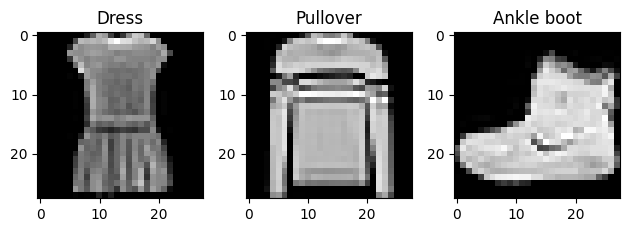

In [5]:
# Checking if everything works so far by displayin some images from the dataset
plt.figure()

# Dress
plt.subplot(1, 3, 1)
plt.imshow(xTrain[3], cmap = "gray")
plt.title(classLabels[yTrain[3]])
plt.tight_layout()

# Pullover
plt.subplot(1, 3, 2)
plt.imshow(xTrain[5], cmap = "gray")
plt.title(classLabels[yTrain[5]])
plt.tight_layout()

# Ankle boot
plt.subplot(1, 3, 3)
plt.imshow(xTrain[0], cmap = "gray")
plt.title(classLabels[yTrain[0]])
plt.tight_layout()

plt.show()

### Normalising images

In [ ]:
# Normalising pixel values to 0/1
xTrain = xTrain.astype("float32") / 255.0
xTest = xTest.astype("float32") / 255.0

# Adding channel dimension for CNN. Images are grayscale, so the channel is 1
xTrain = xTrain.reshape(-1, 28, 28, 1)
xTest = xTest.reshape(-1, 28, 28, 1)

# Checking the normalised shape
print("Reshaped training data:", xTrain.shape)
print("Reshaped test data:", xTest.shape)

Reshaped training data: (60000, 28, 28, 1)
Reshaped test data: (10000, 28, 28, 1)


### One-hot encoding labels

In [7]:
# Encoding labels so they're usable by the algorithm
yTrainCategory = to_categorical(yTrain, 10)
yTestCategory = to_categorical(yTest, 10)

print("Encoded training labels:", yTrainCategory.shape)
print("Encoded test labels:", yTestCategory.shape)

Encoded training labels: (60000, 10)
Encoded test labels: (10000, 10)


### Creating a validation set

In [8]:
# Declaring a validation set, so the performance can be checked whilst the model trains
xTrain, xValidation, yTrainCategory, yValidationCategory = train_test_split(xTrain, yTrainCategory, test_size = 0.2, random_state = 42,
                                                                           stratify = yTrain)

print("Training set:", xTrain.shape)
print("Validation set:", xValidation.shape)

Training set: (48000, 28, 28, 1)
Validation set: (12000, 28, 28, 1)


### Augmenting data

In [9]:
# Transforming and shifting data for better performance in the learning process
# Source for the code below: https://www.tensorflow.org/api_docs/python/tf/keras/preprocessing/image/ImageDataGenerator
trainDataGenerator = ImageDataGenerator(rotation_range = 10, width_shift_range = 0.1, height_shift_range = 0.1, zoom_range = 0.1)

validationDataGenerator = ImageDataGenerator()

trainGenerator = trainDataGenerator.flow(xTrain, yTrainCategory, batch_size = 64)
validationGenerator = validationDataGenerator.flow(xValidation, yValidationCategory, batch_size = 64, shuffle = False)

## Model Architecture

### Creating the model

In [10]:
# Building a CNN with an input layer and three convolutional blocks for feature extraction
model = Sequential([Input(shape = (28, 28, 1)), Conv2D(32, (3, 3), activation = "relu", padding = "same"), BatchNormalization(),
                  MaxPooling2D((2, 2)), Conv2D(64, (3, 3), activation = "relu", padding = "same"), BatchNormalization(),
                  MaxPooling2D((2, 2)), Conv2D(128, (3, 3), activation = "relu", padding = "same"), BatchNormalization(),
                  Flatten(), Dense(128, activation = "relu"), Dropout(0.3), Dense(10, activation = "softmax")])

### Compiling the model

In [11]:
# Compiling the model
model.compile(optimizer = Adam(learning_rate = 0.001), loss = "categorical_crossentropy", metrics = ["accuracy"])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       802,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 897,802 (3.42 MB)

 Trainable params: 897,354 (3.42 MB)

 Non-trainable params: 448 (1.75 KB)

## Training and Evaluation

### Callbacks

In [12]:
# Stopping the training when val_loss stops improving
earlyStopping = EarlyStopping(monitor = "val_loss", patience = 4, restore_best_weights = True, verbose = 1)

# Reducing learning rate when val_loss stops improving
#Source for the code below: https://www.tensorflow.org/api_docs/python/tf/keras/callbacks/ReduceLROnPlateau
reduceLearningRate = ReduceLROnPlateau(monitor = "val_loss", factor = 0.5, patience = 2, min_lr = 1e-6, verbose = 1)

### Training

In [13]:
history = model.fit(trainGenerator, validation_data = validationGenerator, epochs = 10, callbacks = [earlyStopping, reduceLearningRate])

Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 67s 86ms/step - accuracy: 0.7660 - loss: 0.6378 - val_accuracy: 0.8276 - val_loss: 0.4243 - learning_rate: 0.0010
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 67s 89ms/step - accuracy: 0.8267 - loss: 0.4649 - val_accuracy: 0.8423 - val_loss: 0.4527 - learning_rate: 0.0010
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 65s 86ms/step - accuracy: 0.8487 - loss: 0.4143 - val_accuracy: 0.8570 - val_loss: 0.3747 - learning_rate: 0.0010
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 61s 82ms/step - accuracy: 0.8609 - loss: 0.3766 - val_accuracy: 0.8778 - val_loss: 0.3441 - learning_rate: 0.0010
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 61s 82ms/step - accuracy: 0.8685 - loss: 0.3600 - val_accuracy: 0.8723 - val_loss: 0.3632 - learning_rate: 0.0010
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - accuracy: 0.8670 - loss: 0.3534
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
750/750 ━━━━━━━━━━━━━━━━━━━━ 59s 79ms/step - accuracy: 0.8706 - los

### Plotting results

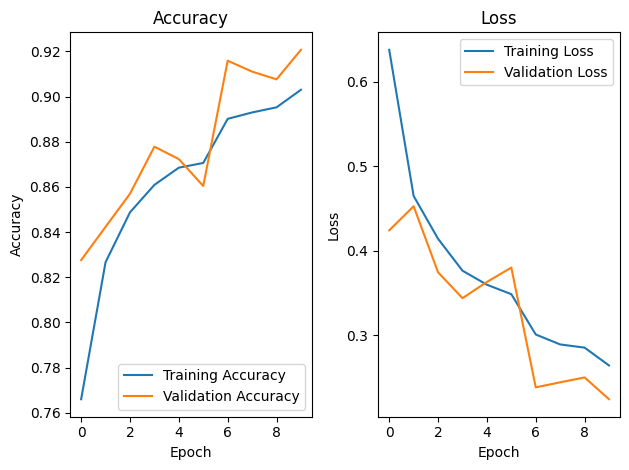

In [14]:
# Plotting training vs validation accuracy & loss
plt.figure()

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label = "Training Accuracy")
plt.plot(history.history["val_accuracy"], label = "Validation Accuracy")
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

# Loss
plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label = "Training Loss")
plt.plot(history.history["val_loss"], label = "Validation Loss")
plt.title("Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

### Evaluating

In [15]:
# Checking the results on the test data
testLoss, testAccuracy = model.evaluate(xTest, yTestCategory, verbose = 1)

print("Test Loss:", testLoss)
print("Test Accuracy:", testAccuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9098 - loss: 0.2472
Test Loss: 0.24719937145709991
Test Accuracy: 0.9097999930381775


### Predicting

In [16]:
# Making a prediction
yPredict = model.predict(xTest)
yPredictClasses = np.argmax(yPredict, axis = 1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


### Classification report

In [17]:
# A short report on each label
print(classification_report(yTest, yPredictClasses, target_names = classLabels))

              precision    recall  f1-score   support

 T-shirt/top       0.90      0.83      0.86      1000
     Trouser       0.99      0.98      0.99      1000
    Pullover       0.88      0.85      0.87      1000
       Dress       0.93      0.87      0.90      1000
        Coat       0.87      0.84      0.86      1000
      Sandal       0.98      0.99      0.99      1000
       Shirt       0.69      0.81      0.74      1000
     Sneaker       0.95      0.97      0.96      1000
         Bag       0.99      0.99      0.99      1000
  Ankle boot       0.98      0.95      0.96      1000

    accuracy                           0.91     10000
   macro avg       0.91      0.91      0.91     10000
weighted avg       0.91      0.91      0.91     10000



### Predictions

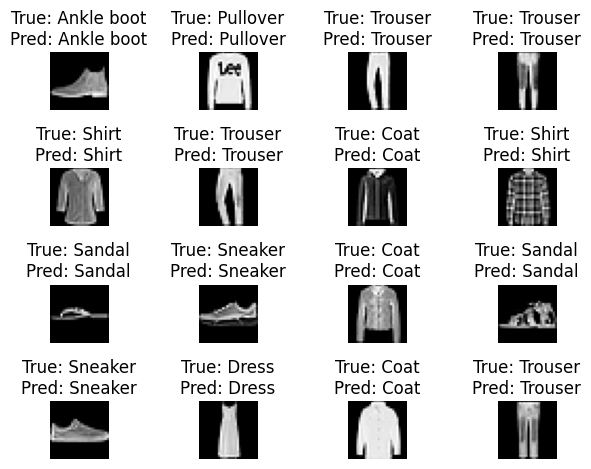

In [18]:
# Checking for 16 predictions
plt.figure()

for i in range(16):
    plt.subplot(4, 4, i + 1)
    plt.imshow(xTest[i].reshape(28, 28), cmap = "gray")
    plt.title(f"True: {classLabels[yTest[i]]}\nPred: {classLabels[yPredictClasses[i]]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

## Model Improvement and Optimization

### Creating a deeper model

In [19]:
# Added more layers to make the model deeper
deeperModel = Sequential([Input(shape = (28, 28, 1)), Conv2D(32, (3, 3), activation = "relu", padding = "same"), BatchNormalization(),
                           Conv2D(32, (3, 3), activation = "relu", padding = "same"), MaxPooling2D((2, 2)), Dropout(0.25),
                           Conv2D(64, (3, 3), activation = "relu", padding = "same"), BatchNormalization(),
                           Conv2D(64, (3, 3), activation = "relu", padding = "same"), MaxPooling2D((2, 2)), Dropout(0.25), Flatten(),
                           Dense(128, activation = "relu"), BatchNormalization(), Dropout(0.4), Dense(10, activation = "softmax")])

# Compiling the model
deeperModel.compile(optimizer = Adam(learning_rate = 0.0005), loss = "categorical_crossentropy", metrics = ["accuracy"])

deeperModel.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 14, 14, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       401,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 468,714 (1.79 MB)

 Trainable params: 468,266 (1.79 MB)

 Non-trainable params: 448 (1.75 KB)

### Training the deeper model

In [20]:
# Training the new model
improvedHistory = deeperModel.fit(trainGenerator, validation_data = validationGenerator, epochs = 20,
                                 callbacks = [earlyStopping, reduceLearningRate])

Epoch 1/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 67s 86ms/step - accuracy: 0.7165 - loss: 0.7826 - val_accuracy: 0.8403 - val_loss: 0.4239 - learning_rate: 5.0000e-04
Epoch 2/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 0.7965 - loss: 0.5535
Epoch 2: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
750/750 ━━━━━━━━━━━━━━━━━━━━ 64s 85ms/step - accuracy: 0.8038 - loss: 0.5333 - val_accuracy: 0.8727 - val_loss: 0.3395 - learning_rate: 5.0000e-04
Epoch 3/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 64s 85ms/step - accuracy: 0.8344 - loss: 0.4502 - val_accuracy: 0.8770 - val_loss: 0.3380 - learning_rate: 2.5000e-04
Epoch 4/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 0.8449 - loss: 0.4183
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.
750/750 ━━━━━━━━━━━━━━━━━━━━ 64s 85ms/step - accuracy: 0.8466 - loss: 0.4168 - val_accuracy: 0.8876 - val_loss: 0.3096 - learning_rate: 2.5000e-04
Epoch 4: early stopping
Restoring model weights from the end of 

### Evaluating the deeper model

In [21]:
# Evaluation
improvedTestLoss, improvedTestAccuracy = deeperModel.evaluate(xTest, yTestCategory, verbose = 1)

print("Improved Model Test Loss:", improvedTestLoss)
print("Improved Model Test Accuracy:", improvedTestAccuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8310 - loss: 0.4413
Improved Model Test Loss: 0.4413033723831177
Improved Model Test Accuracy: 0.8309999704360962


## Short Report

### Introduction

This CA focused on building a ML model to classify Zalando's items using the Fashion-MNIST dataset, which contains 28x28 grayscale images across various categories, such as trouser, sneaker, ankle boot, etc. The aim was to create a CNN that could learn the patterns from the images and correctly classify unseen examples. The project was mainly based on one of the examples covered in class, but it was adapted to better suit the smaller and simpler problem.

### Data Pre-Processing and Augmentation

Firstly, custom loading functions were used to load both the images and the labels. After loading the files, the shapes of both the training and the test dataset were checked to confirm suitability. A few sample images were also displayed to confirm it, too.<br>
Secondly, the pixels were normalised from 0-255 to 0-1 to make the process more stable. The images were also reshaped to add a single-channel dimension, since it's expected by CNNs and Fashion-MNIST is a grayscale dataset. The labels were one-hot encoded to make sure they were used properly by the algorithm. Subsequently, the training data was split into a traning and a validation set (80%-20%), with stratification used to keep the class distribution balanced.<br>
To generalise the model, augmentation was applied: rotations, shift, and zoom changes were used. This was done, so the model did not rely too heavily on exact positions of objects within images. The validation set was not changed, to ensure the performance was measured on untouched samples.

### Model Architecture

In terms of the main model, a CNN was designed. Starting with an input layer, followed by three convolutional layers with 32, 64, and 128 filters, respectively. Batch normalisation and max-pooling layers were also included to improve training stability. Then, the output was flattened and passed into a dense layer (128), followed by dropout to reduce overfitting. The final layer used a softmax activation to attempt to classify the images into 10 categories.<br>
This particular model was chosen, because it was more compact and suitable compared to larger architectures, such as AlexNet. A simpler CNN was enough to learn complex features of small and grayscale images. The model had 897,802 parameters - that kept it efficient, whilst still getting strong performance.

### Training and Evaluation

Subsequently, the model was compiled using the Adam optimiser, categorical cross-entropy loss, and accuracy as the evaluation metric. Early stopping was also used, so the training could stop if validation loss wasn't improving to make training more effective. On top of that, ReduceLRONPlateay was added to lower the learning rate in case of a slow down of the progress. These techniques helped in reducing wasting time on redundant epochs.<br>
The model was trained on 10 epochs, with clear improvement over time. Validation accuracy eventually reached 0.9208. When used on the test set, accuracy achieved ~0.9098 with the loss of ~0.2472. The plots also showed that the model was learning well without major overfitting.<br>
A classification report was produced to look at a more detailed performance for each class. Most categories performed very well, although the shirt class had the lowest F1-score out of them all. This was probably caused because of the visual similarities between shirts and other upper-body clothing, such as pullover or T-shirt/top.

### Model Improvement and Optimisation

Then, a deeper model was tested to see whether the performance could be improved or not. This model added extra convolutional and dropout layers, whilst also using a smaller learning rate. However, the deeper model did not perform as good as the base one. It achieved a lower test accuracy (~0.8301) and a higher test loss (~0.4413).<br>
This showed, that a deeper model ≠ improved performance. In this case, the original CNN was a better fit for this particular dataset. It was simpler, more stable and had better overall performance. This comparison was useful, because it showed that the model should match the data, instead of assuming that a more complex architecture will perform better.

### Challenges Encountered

One of the main challenges was loading in the dataset properly from the files provided. Using a built-in loader did not come across and it was too late to change the idea, therefore the issue was resovled by using generative AI. Another challenge was choosing proper parameters for data augmentation. It took several tries to get it right, without changing the images too much.<br>
Another difficulty came from the similarity between certain categories, such as shirt vs pullover, or sneaker vs sandal. This was resolved by using the trial and error method in changing the parameters and layers in the model.

### Conclusion

Overall, a successful CNN was developed for the Fashion-MNIST dataset. The base model combined data pre-processing, augmentation, regularisation and optimisation to achieve high accuracy of >90%. A more complex alternative was also tested, but it did not improve the performance. In the end, the CA showed that a simple CNN can perform very well on this dataset, whilst remaining efficient and easy to train.